# Native phylogenetic likelihood: benchmark vs. the TensorFlow implementation

This notebook compares Treeflow's reference per-site phylogenetic likelihood
(`treeflow.traversal.phylo_likelihood.phylogenetic_likelihood`, a Python-level
`tf.TensorArray` postorder loop) against the **native C++ custom op**
(`treeflow.acceleration.native.native_phylogenetic_likelihood`).

The native op:

* runs Felsenstein's pruning algorithm in compiled C++ as a single TensorFlow
  op (`tf.load_op_library`), parallelised over alignment sites;
* returns the partial likelihoods at every node so that
* the **gradient** w.r.t. the transition-probability matrices is computed
  analytically in a second op that *reuses* those partials (no recomputation of
  the forward traversal), and is registered with TensorFlow autodiff via
  `tf.RegisterGradient` -- so it works transparently inside `tf.GradientTape`.

Both implementations share the exact same call signature, so the native op is a
drop-in replacement.

## Build the op

The shared library is compiled against the installed TensorFlow ABI. If it is
not present yet, build it (this only needs to happen once).

In [1]:
from treeflow.acceleration.native import phylo_likelihood as native_mod

if not native_mod.is_available():
    from treeflow.acceleration.native.build import build
    build()

print("native op available:", native_mod.is_available())

Silencing TensorFlow...


I0000 00:00:1781248667.352434   23679 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781248667.352976   23679 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1781248668.751551   23679 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781248668.751919   23679 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


native op available: True


In [2]:
import time
import numpy as np
import tensorflow as tf

from treeflow.tree.topology.numpy_tree_topology import NumpyTreeTopology
from treeflow.tree.topology.tensorflow_tree_topology import numpy_topology_to_tensor
from treeflow.traversal.phylo_likelihood import phylogenetic_likelihood as reference
from treeflow.acceleration.native import native_phylogenetic_likelihood as native

tf.get_logger().setLevel("ERROR")

## A random problem generator

We build a random binary tree (children always have a smaller node index than
their parent, the convention Treeflow uses), random one-hot leaf sequences, and
random row-stochastic per-branch transition matrices broadcast over sites.

In [3]:
def make_problem(leaf_count, state_count, site_count, seed=0, dtype=tf.float64):
    rng = np.random.default_rng(seed)
    node_count = 2 * leaf_count - 1
    parent = np.full(node_count, -1, dtype=np.int32)
    active = list(range(leaf_count))
    nxt = leaf_count
    while len(active) > 1:
        a = active.pop(rng.integers(len(active)))
        b = active.pop(rng.integers(len(active)))
        parent[a] = parent[b] = nxt
        active.append(nxt)
        nxt += 1
    topology = numpy_topology_to_tensor(NumpyTreeTopology(parent_indices=parent[:-1]))

    states = rng.integers(0, state_count, size=(site_count, leaf_count))
    sequences = tf.constant(np.eye(state_count, dtype=dtype.as_numpy_dtype)[states])

    probs = rng.uniform(0.1, 1.0, size=(1, node_count, state_count, state_count))
    probs /= probs.sum(axis=-1, keepdims=True)
    probs = tf.constant(probs, dtype=dtype)

    freqs = tf.constant(np.full(state_count, 1.0 / state_count), dtype=dtype)
    return dict(
        sequences=sequences,
        transition_probs=probs,
        frequencies=freqs,
        postorder=topology.postorder_node_indices,
        child_indices=topology.node_child_indices,
    )

## Correctness check

The native op should reproduce the reference likelihood and its gradient to
floating-point precision.

In [4]:
p = make_problem(leaf_count=16, state_count=4, site_count=200, seed=3)
batch_shape = tf.shape(p["sequences"])[:1]

ref_ll = reference(p["sequences"], p["transition_probs"], p["frequencies"],
                   p["postorder"], p["child_indices"], batch_shape=batch_shape)
nat_ll = native(p["sequences"], p["transition_probs"], p["frequencies"],
                p["postorder"], p["child_indices"])

print("max |reference - native| (per-site likelihood):",
      float(tf.reduce_max(tf.abs(ref_ll - nat_ll))))


def grad_wrt_probs(fn, batch):
    probs = tf.Variable(p["transition_probs"])
    with tf.GradientTape() as tape:
        kw = dict(batch_shape=batch_shape) if batch else {}
        ll = fn(p["sequences"], probs, p["frequencies"],
                p["postorder"], p["child_indices"], **kw)
        loss = tf.reduce_sum(tf.math.log(ll))
    return tape.gradient(loss, probs)


ref_g = grad_wrt_probs(reference, batch=True)
nat_g = grad_wrt_probs(native, batch=False)
print("max |reference - native| (d loglik / d transition_probs):",
      float(tf.reduce_max(tf.abs(ref_g - nat_g))))

max |reference - native| (per-site likelihood): 6.203854594147708e-25


max |reference - native| (d loglik / d transition_probs): 5.684341886080802e-14


## Timing helpers

We compare graph-mode (`tf.function`) execution of both implementations, for
the likelihood and for the value-and-gradient together.

In [5]:
def timeit(fn, *args, repeats=30, **kwargs):
    fn(*args, **kwargs)  # warm up / trace
    start = time.perf_counter()
    for _ in range(repeats):
        out = fn(*args, **kwargs)
    out = tf.nest.map_structure(lambda t: t.numpy(), out)
    return (time.perf_counter() - start) / repeats * 1e3  # ms


def benchmark(leaf_count, site_count, state_count=4, seed=0):
    p = make_problem(leaf_count, state_count, site_count, seed=seed)
    batch = tf.shape(p["sequences"])[:1]
    args_ref = (p["sequences"], p["transition_probs"], p["frequencies"],
                p["postorder"], p["child_indices"])

    ref_fn = tf.function(lambda *a: reference(*a, batch_shape=batch))
    nat_fn = tf.function(native)
    t_ref = timeit(ref_fn, *args_ref)
    t_nat = timeit(nat_fn, *args_ref)

    @tf.function
    def ref_vg(probs):
        with tf.GradientTape() as tape:
            tape.watch(probs)
            loss = tf.reduce_sum(tf.math.log(
                reference(p["sequences"], probs, p["frequencies"],
                          p["postorder"], p["child_indices"], batch_shape=batch)))
        return loss, tape.gradient(loss, probs)

    @tf.function
    def nat_vg(probs):
        with tf.GradientTape() as tape:
            tape.watch(probs)
            loss = tf.reduce_sum(tf.math.log(
                native(p["sequences"], probs, p["frequencies"],
                       p["postorder"], p["child_indices"])))
        return loss, tape.gradient(loss, probs)

    probs = tf.constant(p["transition_probs"])
    t_ref_g = timeit(ref_vg, probs)
    t_nat_g = timeit(nat_vg, probs)
    return dict(leaf_count=leaf_count, site_count=site_count,
                ref_ms=t_ref, nat_ms=t_nat, ll_speedup=t_ref / t_nat,
                ref_grad_ms=t_ref_g, nat_grad_ms=t_nat_g,
                grad_speedup=t_ref_g / t_nat_g)

## Run the sweep

In [6]:
configs = [
    (8, 500), (16, 500), (32, 1000), (64, 1000), (128, 2000),
]
rows = [benchmark(L, sites) for (L, sites) in configs]

header = f"{'leaves':>6} {'sites':>6} | {'ref ms':>8} {'native ms':>9} {'speedup':>7} | "
header += f"{'ref grad':>9} {'nat grad':>9} {'speedup':>7}"
print(header)
print("-" * len(header))
for r in rows:
    print(f"{r['leaf_count']:>6} {r['site_count']:>6} | "
          f"{r['ref_ms']:>8.2f} {r['nat_ms']:>9.2f} {r['ll_speedup']:>6.1f}x | "
          f"{r['ref_grad_ms']:>9.2f} {r['nat_grad_ms']:>9.2f} {r['grad_speedup']:>6.1f}x")

leaves  sites |   ref ms native ms speedup |  ref grad  nat grad speedup
------------------------------------------------------------------------
     8    500 |     1.40      0.54    2.6x |      2.34      0.61    3.8x
    16    500 |     2.53      0.61    4.1x |      4.24      0.84    5.1x
    32   1000 |     6.30      0.86    7.4x |     12.68      1.47    8.6x
    64   1000 |    12.35      1.03   12.0x |     25.40      2.25   11.3x
   128   2000 |    38.44      2.14   17.9x |     94.03      7.14   13.2x


## Plot the speedups

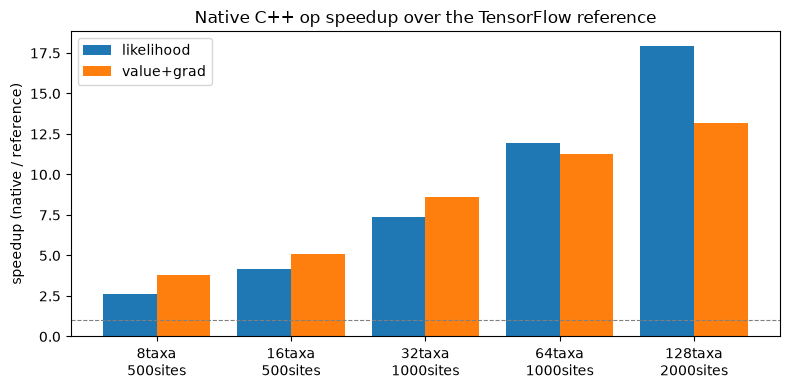

In [7]:
import matplotlib.pyplot as plt

labels = [f"{r['leaf_count']}taxa\n{r['site_count']}sites" for r in rows]
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, [r["ll_speedup"] for r in rows], width=0.4, label="likelihood")
ax.bar(x + 0.2, [r["grad_speedup"] for r in rows], width=0.4, label="value+grad")
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("speedup (native / reference)")
ax.set_title("Native C++ op speedup over the TensorFlow reference")
ax.legend()
fig.tight_layout()
plt.show()

## Rescaling: numerical stability on large trees

On large/deep trees the partial likelihoods underflow to zero, so the linear
likelihood is `0` and its log is `-inf`. The **rescaled** variants divide the
partials at each internal node by their per-site maximum and accumulate the log
scale factors, returning a finite per-site **log** likelihood. There is a
rescaled version of both the native op
(`native_phylogenetic_log_likelihood_rescaled`) and the TensorFlow
implementation
(`treeflow.traversal.phylo_likelihood.phylogenetic_log_likelihood_rescaled`).

In [8]:
from treeflow.acceleration.native import native_phylogenetic_log_likelihood_rescaled

big = make_problem(leaf_count=600, state_count=4, site_count=5, seed=11)

unrescaled = native(big["sequences"], big["transition_probs"], big["frequencies"],
                    big["postorder"], big["child_indices"])
rescaled = native_phylogenetic_log_likelihood_rescaled(
    big["sequences"], big["transition_probs"], big["frequencies"],
    big["postorder"], big["child_indices"])

print("600 taxa, unrescaled linear likelihood :", unrescaled.numpy())
print("600 taxa, log(unrescaled)  [underflow] :", tf.math.log(unrescaled).numpy())
print("600 taxa, rescaled log-likelihood      :", rescaled.numpy())

600 taxa, unrescaled linear likelihood : [0. 0. 0. 0. 0.]
600 taxa, log(unrescaled)  [underflow] : [-inf -inf -inf -inf -inf]
600 taxa, rescaled log-likelihood      : [-856.45855554 -846.28767355 -857.98028924 -849.77934022 -836.55275631]


### Letting the library choose: the dispatcher

`phylogenetic_log_likelihood(..., rescaling=...)` returns the per-site log
likelihood and trades off performance vs. stability:

* `False` — never rescale (fastest, may underflow),
* `True` — always rescale (most stable),
* `"auto"` (default) — decide statically from the leaf count and dtype,
* `"adaptive"` — compute unscaled and fall back to rescaled only if it
  underflows.

Pass `use_native=True` to use the native ops.

In [9]:
from treeflow.traversal.phylo_likelihood_dispatch import (
    phylogenetic_log_likelihood, default_rescaling_threshold)

print("auto threshold (float64):", default_rescaling_threshold(tf.float64), "taxa")
print("auto threshold (float32):", default_rescaling_threshold(tf.float32), "taxa")

for mode in [False, True, "auto", "adaptive"]:
    ll = phylogenetic_log_likelihood(
        big["sequences"], big["transition_probs"], big["frequencies"],
        big["postorder"], big["child_indices"], use_native=True, rescaling=mode)
    finite = bool(tf.reduce_all(tf.math.is_finite(ll)))
    print(f"rescaling={mode!r:>10}: total log-lik = {float(tf.reduce_sum(ll)):>14.4f}  finite={finite}")

auto threshold (float64): 184 taxa
auto threshold (float32): 22 taxa
rescaling=     False: total log-lik =           -inf  finite=False
rescaling=      True: total log-lik =     -4247.0586  finite=True


rescaling=    'auto': total log-lik =     -4247.0586  finite=True
rescaling='adaptive': total log-lik =     -4247.0586  finite=True


### Cost of rescaling on a tree that does not need it

Rescaling adds a per-node max + divide + log, so on small trees it is pure
overhead — which is exactly why `"auto"` skips it below the threshold.

In [10]:
small = make_problem(leaf_count=32, state_count=4, site_count=1000, seed=4)
args = (small["sequences"], small["transition_probs"], small["frequencies"],
        small["postorder"], small["child_indices"])

unscaled_fn = tf.function(lambda *a: tf.math.log(native(*a)))
rescaled_fn = tf.function(native_phylogenetic_log_likelihood_rescaled)
t_unscaled = timeit(unscaled_fn, *args)
t_rescaled = timeit(rescaled_fn, *args)
print(f"32 taxa x 1000 sites: unrescaled {t_unscaled:.2f} ms | "
      f"rescaled {t_rescaled:.2f} ms | overhead {t_rescaled / t_unscaled:.2f}x")

32 taxa x 1000 sites: unrescaled 0.84 ms | rescaled 1.06 ms | overhead 1.26x


## Notes

* The native op is exact: it computes the same Felsenstein recursion in double
  precision, and its analytic gradient matches both the reference autodiff
  gradient and finite differences (see `test/acceleration/native/`).
* It also accepts per-batch (non-broadcast) transition matrices, e.g. for
  discrete rate-category mixtures, and exposes a gradient w.r.t. the root
  frequencies.
* The rescaled variant keeps the likelihood finite on large/deep trees; its
  analytic gradient matches the unrescaled one to floating-point precision.
* To use it inside a model, pass `use_native=True` and `rescaling=...` to
  `treeflow.distributions.leaf_ctmc.LeafCTMC`.